In [1]:
from kid233.stdimp import *
from kid233.model.transmission_line import get_mstrip_params
get_mstrip_params = np.vectorize(get_mstrip_params)
from scipy.integrate import cumulative_trapezoid

In [2]:
eps_sub = 11.9
eps_sup = 1
w_Nb = 2e-6
h_sub = 1.07e-6

### Impedance matching Nb to Al

In [3]:
freq_arr = np.linspace(200, 300, 10)*1e9
w_Al_arr = np.linspace(0.2, 5, 50)*1e-6
R_sq_arr = np.linspace(.1, 1, 50)
w_Nb_arr = np.arange(1, 10, 1)*1e-6

F, W_Nb, W_Al, R = np.meshgrid(freq_arr, w_Nb_arr, w_Al_arr, R_sq_arr, indexing='ij')
_, _, _, Z1 = get_mstrip_params(eps_sub, eps_sup, W_Al, h_sub, R, F)
_, _, _, Z0_Nb = get_mstrip_params(eps_sub, eps_sup, W_Nb, h_sub, 0, F)
Gamma = (Z1/2 - Z0_Nb)/(Z1/2 + Z0_Nb)

# outpath = '/Users/elijahkane/Documents/citresearch/Superspec design/LWCam/Al Nb impedance match/'
# np.save(outpath+'Gamma.npy', Gamma)
# np.save(outpath+'freq.npy', F)
# np.save(outpath+'Nb_width.npy', W_Nb)
# np.save(outpath+'Al_width.npy', W_Al)
# np.save(outpath+'R_sq_Al.npy', R)

8e-06


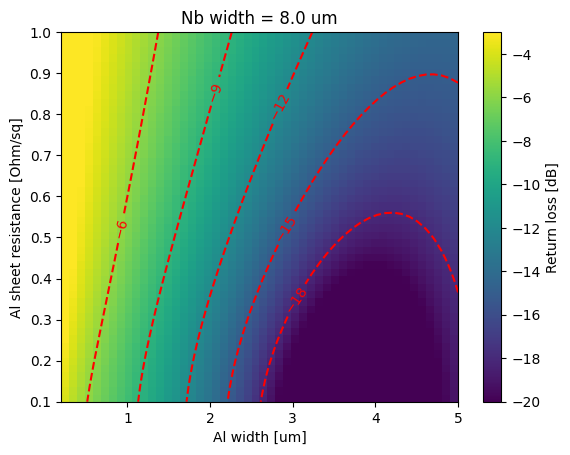

In [7]:
RL = 20*np.log10(abs(Gamma))
max_RL = np.max(RL, axis=0)
iiNb = 7
arr = max_RL[8]
print(w_Nb_arr[iiNb])
x = w_Al_arr*1e6
y = R_sq_arr
X, Y = np.meshgrid(x, y, indexing='ij')
extent = x.min(), x.max(), y.min(), y.max()

fig, ax = plt.subplots()
mappable = ax.imshow(np.flip(arr.T, axis=0), extent=extent, aspect='auto', vmin=-20, vmax=-3)#origin='upper')
CS = ax.contour(X, Y, arr, levels=[-18, -15, -12, -9, -6], colors='red', )#origin='upper')
ax.clabel(CS, fontsize=10)
cbar = fig.colorbar(mappable)
cbar.set_label('Return loss [dB]')
ax.set(xlabel='Al width [um]', ylabel='Al sheet resistance [Ohm/sq]', title=f'Nb width = {w_Nb_arr[iiNb]*1e6:.1f} um')
plt.show()

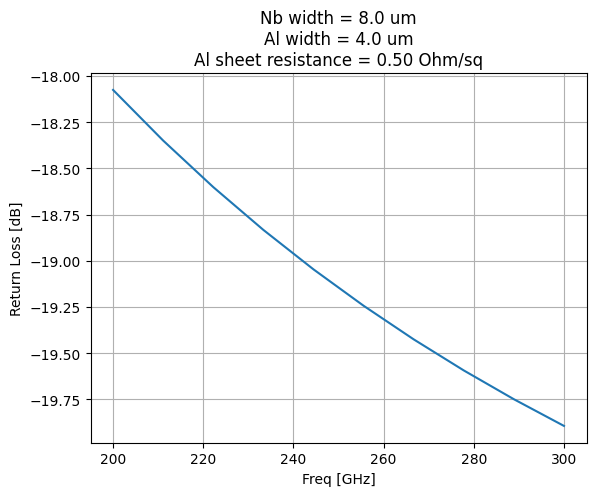

In [6]:
iiNb = 7
iiAl = 39
iiRsq = 33
w_Nb = 8e-6 #w_Nb_arr[iiNb]
w_Al = 4e-6 #w_Al_arr[iiAl]
Rsq = 0.5 #R_sq_arr[iiRsq]
_, _, _, Z0_Nb = get_mstrip_params(eps_sub, eps_sup, w_Nb, h_sub, 0, freq_arr)
_, _, _, Z0_Al = get_mstrip_params(eps_sub, eps_sup, w_Al, h_sub, Rsq, freq_arr)
this_Gamma = (Z0_Al/2 - Z0_Nb)/(Z0_Al/2 + Z0_Nb)
this_RL = 20*np.log10(abs(this_Gamma))

fig, ax = plt.subplots()
ax.plot(freq_arr/1e9, this_RL)
# ax.plot(freq_arr/1e9, RL[:, iiNb, iiAl, iiRsq])
title = f'Nb width = {w_Nb*1e6:.1f} um\nAl width = {w_Al*1e6:.1f} um\nAl sheet resistance = {Rsq:.2f} Ohm/sq'
ax.set(xlabel='Freq [GHz]', ylabel='Return Loss [dB]', title=title)
ax.grid()
plt.show()

# print(w_Nb, w_Al, Rsq)

### Aluminum impedance taper (Linear)

In [8]:
w0 = 4e-6
wf = 0.25e-6
Rsq = 0.5

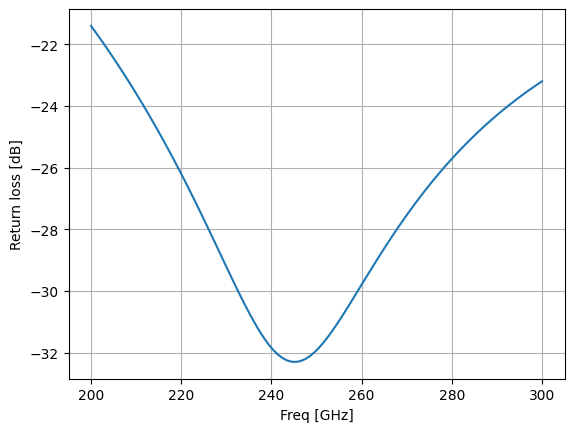

In [9]:
### Linear taper

npts = 1000
xtot = 180e-6

x_arr = np.linspace(0, xtot, npts)
w_arr = np.linspace(w0, wf, npts)
freq_arr = np.linspace(200, 300, 100)*1e9
W, F = np.meshgrid(w_arr, freq_arr, indexing='ij')
R = Rsq/W # Ohm m-1
eps, L, C, Z0 = get_mstrip_params(eps_sub, eps_sup, W, h_sub, Rsq, F)
omega = 2*np.pi*F
gamma = ((R + 1j*omega*L)*1j*omega*C)**.5

dx = x_arr[1]-x_arr[0]
dZ0 = np.diff(Z0, axis=0)
phase = cumulative_trapezoid(gamma, x_arr, axis=0)
integrand = np.exp(-2*phase)/Z0[:-1, :] * dZ0 / dx
Gamma = .5 * np.trapezoid(integrand, x_arr[:-1], axis=0)

fig, ax = plt.subplots()
ax.plot(freq_arr/1e9, 20*np.log10(np.abs(Gamma)))
ax.set(xlabel='Freq [GHz]', ylabel='Return loss [dB]')
ax.grid()
plt.show()

In [12]:
### Reflection coefficient if we did no tapering

# Z1 = Z0_arr[0]
# Z2 = Z0_arr[-1]
# Gamma = (Z2-Z1)/(Z2+Z1)
# print(f'Return loss = {20*np.log10(abs(Gamma)):.1f} dB')

### Nb impedance taper (Linear)

In [15]:
w0 = 8e-6
wf = 2e-6

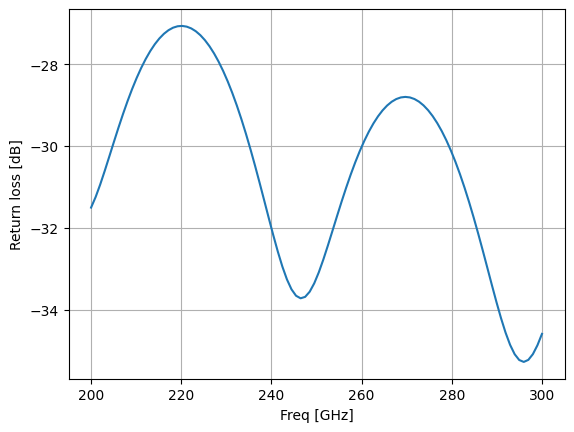

In [16]:
### Linear taper

fig, ax = plt.subplots()

npts = 1000
xtot = 1000e-6

x_arr = np.linspace(0, xtot, npts)
w_arr = np.linspace(w0, wf, npts)
freq_arr = np.linspace(200, 300, 100)*1e9
W, F = np.meshgrid(w_arr, freq_arr, indexing='ij')
eps, L, C, Z0 = get_mstrip_params(eps_sub, eps_sup, W, h_sub, 0, F)
omega = 2*np.pi*F
gamma = 1j*omega*(L*C)**.5

dx = x_arr[1]-x_arr[0]
dZ0 = np.diff(Z0, axis=0)
phase = cumulative_trapezoid(gamma, x_arr, axis=0)
integrand = np.exp(-2*phase)/Z0[:-1, :] * dZ0 / dx
Gamma = .5 * np.trapezoid(integrand, x_arr[:-1], axis=0)

ax.plot(freq_arr/1e9, 20*np.log10(np.abs(Gamma)))
ax.set(xlabel='Freq [GHz]', ylabel='Return loss [dB]')
ax.grid()

### Nb impedance taper (Klopfenstein)

In [17]:
import importlib
import klopfenstein
importlib.reload(klopfenstein)

w0 = 8e-6
wf = 2e-6
wsamp = np.linspace(w0, wf, 50)

fLow = 180e9
fHigh = 320e9
startFreq = 150e9
freqStep = 10e6
stopFreq = 350e9
numSections = 100
eps, L, C, Z0 = get_mstrip_params(eps_sub, eps_sup, wsamp, h_sub, 0, 250e9)
Z0 = np.real(Z0)
er = np.mean(eps)
ZS = Z0[0]
ZL = Z0[-1]
MaxRL = -30
L, freq, Z, RL = klopfenstein.calculate_klopfenstein_taper(fLow, fHigh, startFreq, freqStep, stopFreq,
                                                          numSections, er, ZS, ZL, MaxRL)

l = L/numSections
# Z = np.append(ZS, np.append(Z, ZL))
xarr = np.arange(len(Z))*l
warr = np.interp(Z, Z0, wsamp)

/Users/elijahkane/opt/miniconda3/miniconda3/envs/cit/lib/python3.12/site-packages/scipy-1.14.1-py3.12-macosx-10.15-x86_64.egg/scipy/integrate/_quadpack_py.py:606: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagse(func,a,b,args,full_output,epsabs,epsrel,limit)


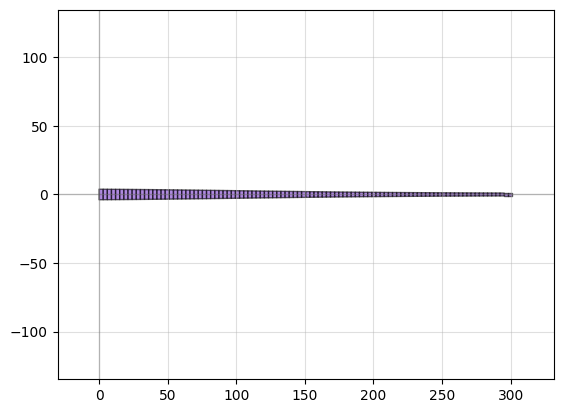

In [18]:
import phidl.geometry as pg
from phidl import quickplot as qp
import phidl.routing as pr
import phidl.path as pp
from phidl import Path

D = pg.Device()
for ii in range(len(warr)):
    P = Path()
    P.append(pp.straight(length = l*1e6))
    if ii < len(warr)-1:
        wire = P.extrude([warr[ii]*1e6, warr[ii+1]*1e6], layer=4)
    else:
        wire = P.extrude(warr[ii]*1e6, layer=4)
    p = D.add_ref(wire)
    p.move([ii*l*1e6, 0])

%matplotlib inline
qp(D)

In [14]:
outpath = '/Users/elijahkane/Documents/citresearch/Superspec design/LWCam/Nb klopfenstein taper/'
D.write_gds(outpath+'klopfenstein_taper.gds')

'/Users/elijahkane/Documents/citresearch/Superspec design/LWCam/Nb klopfenstein taper/klopfenstein_taper.gds'

In [15]:
# D = pg.import_gds(filename=outpath+'klopfenstein_taper.gds', cellname=None, flatten=False)
# qp(D)

### Calculate Al volume

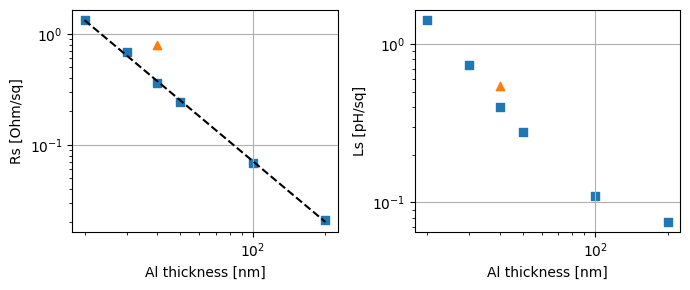

In [14]:
t_Al_Shibo = np.array([20, 30, 40, 50, 100, 200])*1e-9
Rs_Al_Shibo = np.array([1.33, .682, .362, .241, .0691, .0208])
Ls_Al_Shibo = np.array([1.42, .74, .4, .28, .11, .075])*1e-12 # H/sq
t_Al_Andrew = 40e-9
Rs_Al_Andrew = .785
Ls_Al_Andrew = .54e-12

log_t = np.log(t_Al_Shibo)
log_Rs = np.log(Rs_Al_Shibo)
poly = np.polyfit(log_t, log_Rs, deg=1)
log_Rs_fit = np.polyval(poly, log_t)
Rs_fit = np.exp(log_Rs_fit)

fig, (ax0, ax1) = plt.subplots(figsize=(7,3), nrows=1, ncols=2)
ax0.scatter(t_Al_Shibo*1e9, Rs_Al_Shibo, marker='s')
ax0.scatter(t_Al_Andrew*1e9, Rs_Al_Andrew, marker='^')
ax0.plot(t_Al_Shibo*1e9, Rs_fit, 'k--')
ax0.set(xlabel='Al thickness [nm]', ylabel='Rs [Ohm/sq]', xscale='log', yscale='log')
ax0.grid()
ax1.scatter(t_Al_Shibo*1e9, Ls_Al_Shibo*1e12, marker='s')
ax1.scatter(t_Al_Andrew*1e9, Ls_Al_Andrew*1e12, marker='^')
ax1.set(xlabel='Al thickness [nm]', ylabel='Ls [pH/sq]', xscale='log', yscale='log')
ax1.grid()
plt.tight_layout()
plt.show()

In [15]:
t_Al = np.interp(Rsq, np.flip(Rs_Al_Shibo), np.flip(t_Al_Shibo))
Ls_Al = np.interp(t_Al, t_Al_Shibo, Ls_Al_Shibo)
w0_Al = 4e-6
wf_Al = 0.25e-6
Ltot = 6.9e-9

l0 = 84e-6
l_taper = 165e-6
npts_taper = 100
wtaper = np.linspace(w0_Al, w_Al, npts_taper)
x_taper = np.linspace(0, l_taper, npts_taper)

# get geometric inductance
readout_freq = 500e6
eps, L0, C, Z0 = get_mstrip_params(eps_sub, eps_sup, w0_Al, h_sub, 0, readout_freq) # thick part
eps, Ltaper, C, Z0 = get_mstrip_params(eps_sub, eps_sup, wtaper, h_sub, 0, readout_freq) # taper
eps, Lf, C, Z0 = get_mstrip_params(eps_sub, eps_sup, wf_Al, h_sub, 0, readout_freq) # thin part

Lkin_per_l_0 = Ls_Al/w0_Al
Ltot_per_l_0 = Lkin_per_l_0 + L0
Lkin_per_l_taper = Ls_Al/wtaper
Ltot_per_l_taper = Lkin_per_l_taper + Ltaper
Lstart = Ltot_per_l_0 * l0 + np.trapezoid(Ltot_per_l_taper, x_taper)
Vstart = (l0 * w0_Al + l_taper * (w0_Al+wf_Al)/2) * t_Al
Lkin_per_l_f = Ls_Al/wf_Al
Ltot_per_l_f = Lkin_per_l_f + Lf
lf = (Ltot-Lstart)/(Ltot_per_l_f)
Vtot = Vstart + lf*wf_Al*t_Al
Lkin = Lkin_per_l_0*l0 + np.trapezoid(Lkin_per_l_taper, x_taper) + Lkin_per_l_f*lf
alpha = Lkin/Ltot


print(f'Al thickness: {t_Al*1e9:.1f} nm')
print(f'Length of thin section: {lf*1e6:.1f} um')
print(f'Volume: {Vtot*1e18:.2f} um^3')
print(f'Kinetic inductance fraction: {alpha:.2f}')

Al thickness: 35.7 nm
Length of thin section: 2355.9 um
Volume: 45.52 um^3
Kinetic inductance fraction: 0.75


In [30]:
L = 2400 / 0.25 * 0.0017 / (6.28*500e6)

from scipy import constants

C = 11.9 * constants.epsilon_0 * 200 * 1020 * 1e-6 / (2*1.07)

1/(6.28 * (L*C)**.5) / 1e6

696.929840939607

In [40]:
L = 1/((6.28*500e6)**2 * C)
X = 6.28*500e6*L
Xsq = X * 0.25/2400

Xsq

0.00330283618170632

### Scratch

In [ ]:
# Nb transmission line
eps_Nb, L_Nb, C_Nb, Z0_Nb = get_mstrip_params(eps_sub, eps_sup, w_Nb, h_sub, 0, freq)

# Al transmission line
w_Al_arr = np.linspace(0.5, 2, 100)*1e-6
Rsq_Al_arr = np.linspace(.1, 1, 11)
Z0_Al_arr = np.zeros(shape=(len(w_Al_arr), len(Rsq_Al_arr)), dtype=complex)
eps_Al_arr = np.zeros(shape=(len(w_Al_arr), len(Rsq_Al_arr)), dtype=complex)
for i0 in range(len(w_Al_arr)):
    for i1 in range(len(Rsq_Al_arr)):
        eps_Al, LAl, CAl, Z0_Al = get_mstrip_params(eps_sub, eps_sup, w_Al_arr[i0], h_sub, Rsq_Al_arr[i1], freq)
        Z0_Al_arr[i0, i1] = Z0_Al
        eps_Al_arr[i0, i1] = eps_Al
Z0_Al_arr = Z0_Al_arr.T
eps_Al_arr = eps_Al_arr.T

# halve the Al impedance because the current from the Nb line gets split into two Al lines
Gamma_arr = (Z0_Al_arr/2-Z0_Nb)/(Z0_Al_arr/2+Z0_Nb)
RL_arr = 20*np.log10(np.abs(Gamma_arr))

fig, ax = plt.subplots()
for ii in range(len(Rsq_Al_arr)):
    ax.plot(w_Al_arr*1e6, RL_arr[ii], label=f'{Rsq_Al_arr[ii]:.2f}', alpha=0.7)
ax.set(xlabel='Al trace width [um]', ylabel='Return Loss [dB]')
ax.legend(bbox_to_anchor=[1.2,.5], title='Al sheet resistance [Ohm/sq]')
ax.grid()

In [ ]:
# Nb transmission line
eps_Nb, L_Nb, C_Nb, Z0_Nb = get_mstrip_params(eps_sub, eps_sup, w_Nb, h_sub, 0, freq)

# Al transmission line
w_Al_arr = np.linspace(0.5, 2, 11)*1e-6
Rsq_Al_arr = np.linspace(.01, 2, 100)
Z0_Al_arr = np.zeros(shape=(len(w_Al_arr), len(Rsq_Al_arr)), dtype=complex)
eps_Al_arr = np.zeros(shape=(len(w_Al_arr), len(Rsq_Al_arr)), dtype=complex)
for i0 in range(len(w_Al_arr)):
    for i1 in range(len(Rsq_Al_arr)):
        eps_Al, LAl, CAl, Z0_Al = get_mstrip_params(eps_sub, eps_sup, w_Al_arr[i0], h_sub, Rsq_Al_arr[i1], freq)
        Z0_Al_arr[i0, i1] = Z0_Al
        eps_Al_arr[i0, i1] = eps_Al

# halve the Al impedance because the current from the Nb line gets split into two Al lines
Gamma_arr = (Z0_Al_arr/2-Z0_Nb)/(Z0_Al_arr/2+Z0_Nb)
RL_arr = 20*np.log10(np.abs(Gamma_arr))

fig, ax = plt.subplots()
for ii in range(len(w_Al_arr)):
    ax.plot(Rsq_Al_arr, RL_arr[ii], label=f'{w_Al_arr[ii]*1e6:.2f}', alpha=0.7)
ax.set(xlabel='Al sheet resistance [Ohms/sq]', ylabel='Return Loss [dB]')
ax.legend(bbox_to_anchor=[1.2,.5], title='Al trace width [um]')
ax.grid()

In [79]:
### Nb thickness correction

t = 1e-6
t_norm = t/h_sub
u = w_strip/h_sub
u1 = t_norm/np.pi * np.log(1+4*np.exp(1)/(t_norm/np.tanh((6.517*u)**.5)**2))
ur = 1/2 * (1+1/np.cosh((eps_sub-1)**.5)) * u1
ur

np.float64(0.4050235370354184)